# LSTM - HOBO Sensor Sites

In this notebook, we train an LSTM model to predict dry (0) or wet (1) for a given HJ Andrews HOBO Sensor Site 3 days after a given date. The model uses features at time t and the current wet/dry status (target[t]) to predict target[t+3].

Sequences are created per site to avoid cross-site boundary contamination.

We apply ADASYN to the training data and use a random train-test split.

## Imports

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from imblearn.over_sampling import ADASYN
from sklearn.model_selection import train_test_split
np.random.seed(42)
torch.manual_seed(42)

## Data Preprocessing

In [2]:
# Data Paths
DRIVERS_PATH = "../data/sciencebase/met_drivers.csv"
OBS_PATH = "../data/sciencebase/obs.csv"
STATIC_PATH = "../data/sciencebase/static_vars.csv"
DEGREES_PATH = "../data/huggingface/degrees.parquet"

# Load datasets
drivers = pd.read_csv(DRIVERS_PATH)
obs_df = pd.read_csv(OBS_PATH)
static_df = pd.read_csv(STATIC_PATH)
degrees = pd.read_parquet(DEGREES_PATH)

# Extract HOBO wet/dry observations and MaxDepth obs (excluding Discharge)
OBS_EXTRA_COLS = ['MaxDepth_cm', 'MaxDepth_Threshold', 'MaxDepth_Censor']
# obs.csv is already in wide form (one column per observation type),
# so each row has at most one variable populated and the rest are NaN.
hobo_df = obs_df[obs_df['HoboWetDry0.05'].notna()][
    ['NHDPlusID', 'SiteIDCode', 'Date', 'HoboWetDry0.05']
].rename(columns={'HoboWetDry0.05': 'wetdry_status'}).copy()

# MaxDepth columns are already present in wide-form obs_df; keep only rows
# where at least one MaxDepth value is observed.
max_depth_wide = obs_df.loc[
    obs_df[OBS_EXTRA_COLS].notna().any(axis=1),
    ['NHDPlusID', 'Date'] + OBS_EXTRA_COLS,
]

# Normalize types before merging
hobo_df['NHDPlusID'] = hobo_df['NHDPlusID'].astype(str)
drivers['NHDPlusID'] = drivers['NHDPlusID'].astype(str)
static_df['NHDPlusID'] = static_df['NHDPlusID'].astype(str)
max_depth_wide['NHDPlusID'] = max_depth_wide['NHDPlusID'].astype(str)
hobo_df['Date'] = pd.to_datetime(hobo_df['Date'])
drivers['Date'] = pd.to_datetime(drivers['Date'])
max_depth_wide['Date'] = pd.to_datetime(max_depth_wide['Date'])

# static_vars.csv is already in wide form (one column per variable).
static_pivot = static_df

# Merge all datasets
central_df = hobo_df.merge(drivers, on=['NHDPlusID', 'Date'], how='inner')
central_df = central_df.merge(static_pivot, on='NHDPlusID', how='left')
central_df = central_df.merge(degrees, on='NHDPlusID', how='left')
central_df = central_df.merge(max_depth_wide, on=['NHDPlusID', 'Date'], how='left')

# Per-site forward/back-fill on MaxDepth columns to patch temporal gaps.
# Any site with no MaxDepth observation at all falls back to 0.
central_df = central_df.sort_values(['NHDPlusID', 'Date'])
central_df[OBS_EXTRA_COLS] = (
    central_df.groupby('NHDPlusID')[OBS_EXTRA_COLS]
    .transform(lambda g: g.ffill().bfill())
)
central_df[OBS_EXTRA_COLS] = central_df[OBS_EXTRA_COLS].fillna(0)

In [3]:
# Sort by date within each NHDPlusID
central_df = central_df.sort_values(['NHDPlusID', 'Date'])

# Target: wet/dry status 3 days ahead (target[t+3])
central_df['wet_dry_next'] = central_df.groupby('NHDPlusID')['wetdry_status'].shift(-3)

# Drop rows with NaN values from target
central_df = central_df.dropna(subset=['wet_dry_next'])

# Define feature columns (same as XGB/LR)
drop_cols = ['NHDPlusID', 'SiteIDCode', 'Date', 'wet_dry_next']
feature_cols = [c for c in central_df.columns if c not in drop_cols]

# Fill NaNs in features
central_df[feature_cols] = central_df[feature_cols].ffill().bfill().fillna(0)

print(f"Dataset: {len(central_df)} samples, {len(feature_cols)} features")
print(f"Features: {feature_cols}")

Dataset: 2626 samples, 36 features
Features: ['wetdry_status', 'etalfalfa', 'etgrass', 'prcp', 'rhmax', 'rhmin', 'sph', 'srad', 'tmax', 'tmin', 'vp', 'ws', 'aspect_ne_pct', 'aspect_sw_pct', 'aspect_nw_pct', 'aspect_se_pct', 'elev_min_cm', 'elev_max_cm', 'elev_median_cm', 'elev_mean_cm', 'slp_median_pct', 'slp_mean_pct', 'curv_median', 'curv_mean', 'FromNode', 'ToNode', 'ArbolateSu', 'AreaSqKm', 'TotDASqKm', 'Slope', 'LengthKM', 'In-degree', 'Out-degree', 'MaxDepth_cm', 'MaxDepth_Threshold', 'MaxDepth_Censor']


## Model Architecture

In [4]:
SEQ_LEN = 30

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


def create_sequences_by_site(df, site_col, feature_cols, target_col, seq_len=SEQ_LEN):
    """Create sliding window sequences grouped by site to avoid cross-site contamination."""
    X, y = [], []
    for _, group in df.groupby(site_col):
        if len(group) <= seq_len:
            continue
        features = group[feature_cols].values
        labels = group[target_col].values
        for i in range(len(group) - seq_len):
            X.append(features[i:i+seq_len])
            y.append(labels[i + seq_len - 1])
    return np.array(X), np.array(y)

## ADASYN Resampling and Model Training

In [5]:
# Scale features
scaler = StandardScaler()
central_df[feature_cols] = scaler.fit_transform(central_df[feature_cols])

# Create sequences per site (avoids cross-site boundary sequences)
X_all, y_all = create_sequences_by_site(
    central_df, 'NHDPlusID', feature_cols, 'wet_dry_next', seq_len=SEQ_LEN
)
print(f"Sequences: {X_all.shape}, Labels: {y_all.shape}")
print(f"Class distribution — Wet: {int((y_all > 0.5).sum())}, Dry: {int((y_all <= 0.5).sum())}")

# Random train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, shuffle=True, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# ADASYN on training data only (flatten 3D -> 2D, resample, reshape back)
n_samples, seq_length, n_features = X_train.shape
X_flat = X_train.reshape(n_samples, seq_length * n_features)
adasyn = ADASYN(random_state=42)
X_flat_res, y_train_res = adasyn.fit_resample(X_flat, y_train.astype(int))
X_train_res = X_flat_res.reshape(-1, seq_length, n_features)
print(f"After ADASYN — Train: {X_train_res.shape}")

# Train/val split for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_res, y_train_res, test_size=0.2, random_state=42
)

# Convert to tensors
X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr.reshape(-1, 1), dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)

# Model
LSTM_model = LSTMModel(input_size=n_features)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.0]))
optimizer = torch.optim.Adam(LSTM_model.parameters(), lr=1e-4)

# Training loop with early stopping
best_val_loss = float('inf')
best_state = None
patience_counter = 0
epochs = 15

for epoch in range(epochs):
    LSTM_model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = LSTM_model(xb)
        logits = torch.nan_to_num(logits, nan=0.0, posinf=5.0, neginf=-5.0)
        loss = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(LSTM_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    LSTM_model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = LSTM_model(xb)
            logits = torch.nan_to_num(logits, nan=0.0, posinf=5.0, neginf=-5.0)
            val_loss += criterion(logits, yb).item()

    print(f"Epoch {epoch+1}/{epochs} | Train Loss={total_loss/len(train_loader):.4f} | Val Loss={val_loss/len(val_loader):.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in LSTM_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 5:
            print("Early stopping triggered.")
            break

LSTM_model.load_state_dict(best_state)
print("Loaded best model state.")

Sequences: (1966, 30, 36), Labels: (1966,)
Class distribution — Wet: 1610, Dry: 356
Train: (1572, 30, 36), Test: (394, 30, 36)
After ADASYN — Train: (2592, 30, 36)
Epoch 1/15 | Train Loss=0.6748 | Val Loss=0.6515
Epoch 2/15 | Train Loss=0.5809 | Val Loss=0.4596
Epoch 3/15 | Train Loss=0.3008 | Val Loss=0.1762
Epoch 4/15 | Train Loss=0.1553 | Val Loss=0.1268
Epoch 5/15 | Train Loss=0.1210 | Val Loss=0.0942
Epoch 6/15 | Train Loss=0.0871 | Val Loss=0.0719
Epoch 7/15 | Train Loss=0.0742 | Val Loss=0.0598
Epoch 8/15 | Train Loss=0.0731 | Val Loss=0.0553
Epoch 9/15 | Train Loss=0.0665 | Val Loss=0.0538
Epoch 10/15 | Train Loss=0.0577 | Val Loss=0.0569
Epoch 11/15 | Train Loss=0.0567 | Val Loss=0.0496
Epoch 12/15 | Train Loss=0.0580 | Val Loss=0.0538
Epoch 13/15 | Train Loss=0.0606 | Val Loss=0.0520
Epoch 14/15 | Train Loss=0.0569 | Val Loss=0.0457
Epoch 15/15 | Train Loss=0.0546 | Val Loss=0.0535
Loaded best model state.


## Metrics and Feature Importance

Accuracy: 0.9670
ROC-AUC: 0.9797
F1 Score: 0.9793

              precision    recall  f1-score   support

         Dry      0.851     1.000     0.919        74
         Wet      1.000     0.959     0.979       320

    accuracy                          0.967       394
   macro avg      0.925     0.980     0.949       394
weighted avg      0.972     0.967     0.968       394



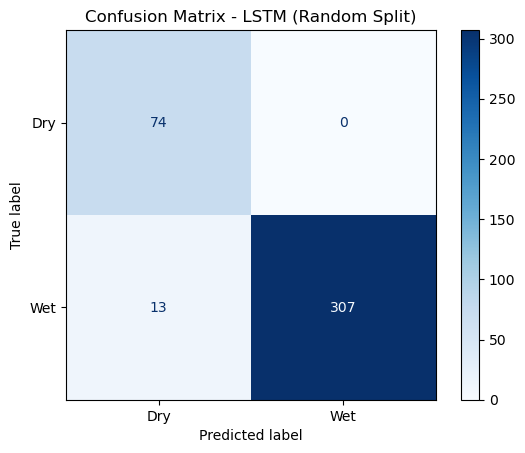

In [6]:
# Predict on test set
X_test_t = torch.tensor(X_test, dtype=torch.float32)

LSTM_model.eval()
with torch.no_grad():
    logits = LSTM_model(X_test_t).squeeze()
    logits = torch.nan_to_num(logits, nan=0.0, posinf=5.0, neginf=-5.0)
    y_probs = torch.sigmoid(logits).numpy()
    y_pred = (y_probs >= 0.5).astype(int)

y_true = y_test.astype(int)

accuracy = accuracy_score(y_true, y_pred)
roc = roc_auc_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc:.4f}")
print(f"F1 Score: {f1:.4f}")

print()
print(classification_report(y_true, y_pred, target_names=['Dry', 'Wet'], digits=3))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dry', 'Wet'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - LSTM (Random Split)")
plt.show()

           Feature  Importance
     wetdry_status    0.044626
    slp_median_pct    0.016543
     aspect_sw_pct    0.016543
      elev_mean_cm    0.014636
        Out-degree    0.014076
       curv_median    0.013083
               sph    0.009862
             Slope    0.009569
         curv_mean    0.008205
              srad    0.008205
     aspect_nw_pct    0.008205
     aspect_ne_pct    0.007838
                vp    0.006554
          AreaSqKm    0.006466
       elev_min_cm    0.004907
             rhmin    0.004907
          FromNode    0.004907
            ToNode    0.003266
              tmin    0.003266
        ArbolateSu    0.003266
       elev_max_cm    0.003190
         TotDASqKm    0.001631
              tmax    0.001631
             rhmax    0.001631
         In-degree   -0.001625
    elev_median_cm   -0.001625
      slp_mean_pct   -0.001625
     aspect_se_pct   -0.000066
         etalfalfa    0.000000
                ws    0.000000
          LengthKM    0.000000
        

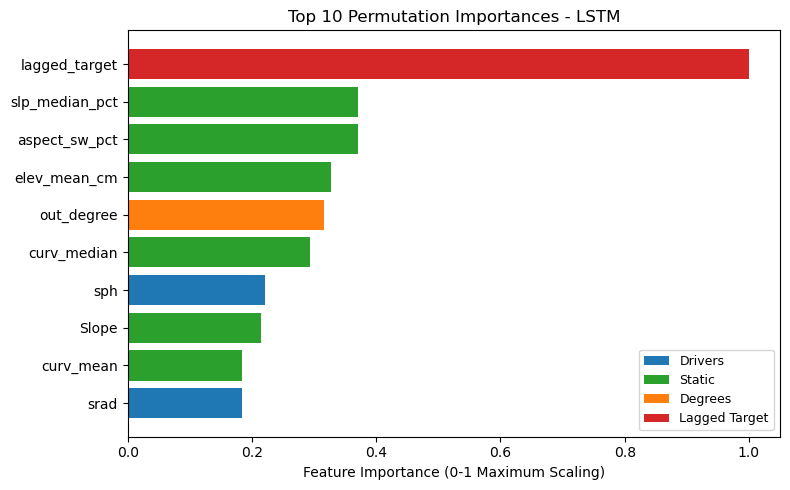

In [7]:
# Permutation importance
LSTM_model.eval()
with torch.no_grad():
    base_probs = torch.sigmoid(LSTM_model(X_test_t).squeeze()).numpy()
base_preds = (base_probs >= 0.5).astype(int)
base_f1 = f1_score(y_true, base_preds)

importances = []
for i, col in enumerate(feature_cols):
    X_perm = X_test.copy()
    X_perm[:, :, i] = np.random.permutation(X_perm[:, :, i])
    X_perm_t = torch.tensor(X_perm, dtype=torch.float32)
    with torch.no_grad():
        perm_probs = torch.sigmoid(LSTM_model(X_perm_t).squeeze()).numpy()
    perm_preds = (perm_probs >= 0.5).astype(int)
    perm_f1 = f1_score(y_true, perm_preds)
    importances.append(base_f1 - perm_f1)

imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
imp_df['Abs_Importance'] = imp_df['Importance'].abs()
imp_df = imp_df.sort_values('Abs_Importance', ascending=False)

print(imp_df[['Feature', 'Importance']].to_string(index=False))

# Scale to 0-1 (max-normalization)
imp_df['Scaled'] = imp_df['Abs_Importance'] / imp_df['Abs_Importance'].max()

# Rename for visualization
imp_df['Feature'] = imp_df['Feature'].replace({
    'Out-degree': 'out_degree',
    'In-degree': 'in_degree',
    'wetdry_status': 'lagged_target',
})

# Color-code feature importances by category (consistent across notebooks)
from matplotlib.patches import Patch

FEATURE_CATEGORIES = {
    'lagged_target': 'Lagged Target',
    'in_degree': 'Degrees',
    'out_degree': 'Degrees',
}
for v in ['tmax', 'tmin', 'srad', 'prcp', 'vp', 'ws',
          'etgrass', 'etalfalfa', 'rhmax', 'rhmin', 'sph']:
    FEATURE_CATEGORIES[v] = 'Drivers'
for v in ['ArbolateSu', 'AreaSqKm', 'TotDASqKm', 'Slope', 'LengthKM',
          'FromNode', 'ToNode',
          'aspect_ne_pct', 'aspect_nw_pct', 'aspect_se_pct', 'aspect_sw_pct',
          'curv_mean', 'curv_median',
          'elev_max_cm', 'elev_mean_cm', 'elev_median_cm', 'elev_min_cm',
          'slp_mean_pct', 'slp_median_pct']:
    FEATURE_CATEGORIES[v] = 'Static'
for v in ['MaxDepth_cm', 'MaxDepth_Threshold', 'MaxDepth_Censor']:
    FEATURE_CATEGORIES[v] = 'Other Obs'

CATEGORY_COLORS = {
    'Lagged Target': '#d62728',  # red
    'Drivers':       '#1f77b4',  # blue
    'Static':        '#2ca02c',  # green
    'Degrees':       '#ff7f0e',  # orange
    'Other Obs':     '#9467bd',  # purple
    'Other':         '#7f7f7f',  # gray
}

def feature_color(name):
    return CATEGORY_COLORS[FEATURE_CATEGORIES.get(name, 'Other')]

def add_category_legend(ax, features):
    seen = []
    for f in features:
        cat = FEATURE_CATEGORIES.get(f, 'Other')
        if cat not in seen:
            seen.append(cat)
    handles = [Patch(facecolor=CATEGORY_COLORS[c], label=c) for c in seen]
    ax.legend(handles=handles, loc='lower right', fontsize=9, frameon=True)

top10 = imp_df.head(10)
features_top = top10['Feature'][::-1].tolist()
values_top   = top10['Scaled'][::-1].tolist()
bar_colors   = [feature_color(f) for f in features_top]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(features_top, values_top, color=bar_colors)
ax.set_xlabel('Feature Importance (0-1 Maximum Scaling)')
ax.set_title('Top 10 Permutation Importances - LSTM')
add_category_legend(ax, features_top)
plt.tight_layout()
plt.show()